In [ ]:
!pip install torch-geometric -q

In [ ]:
import os

if os.path.exists('/kaggle/input'):
    DATA_DIR = '/kaggle/input/datasets/guibmc/dgl-data'
    import sys
    sys.path.append('/kaggle/input/datasets/guibmc/matrixvectorizer')
    KAGGLE = True
else:
    DATA_DIR = 'data'
    KAGGLE = False

from MatrixVectorizer import MatrixVectorizer



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
from scipy.spatial.distance import jensenshannon
import networkx as nx
from MatrixVectorizer import MatrixVectorizer
import time
import psutil
import os

# Reproducibility (matching reproducibility.py)
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA is available. Using GPU.")
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
else:
    device = torch.device("cpu")
    print("CUDA not available. Using CPU.")

/vol/gpudata/gb1625-imaging/dgl-coursework2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA is available. Using GPU.


LR Train: (167, 12720)
HR Train: (167, 35778)
LR Test:  (112, 12720)

LR matrix: (160, 160), symmetric=True, range=[0.0000, 0.9151]
HR matrix: (268, 268), symmetric=True, range=[0.0000, 0.9647]
LR sparsity (==0): 27.6%
HR sparsity (==0): 20.5%
LR mean: 0.1981, HR mean: 0.2599
LR-HR subject mean correlation: 0.9020


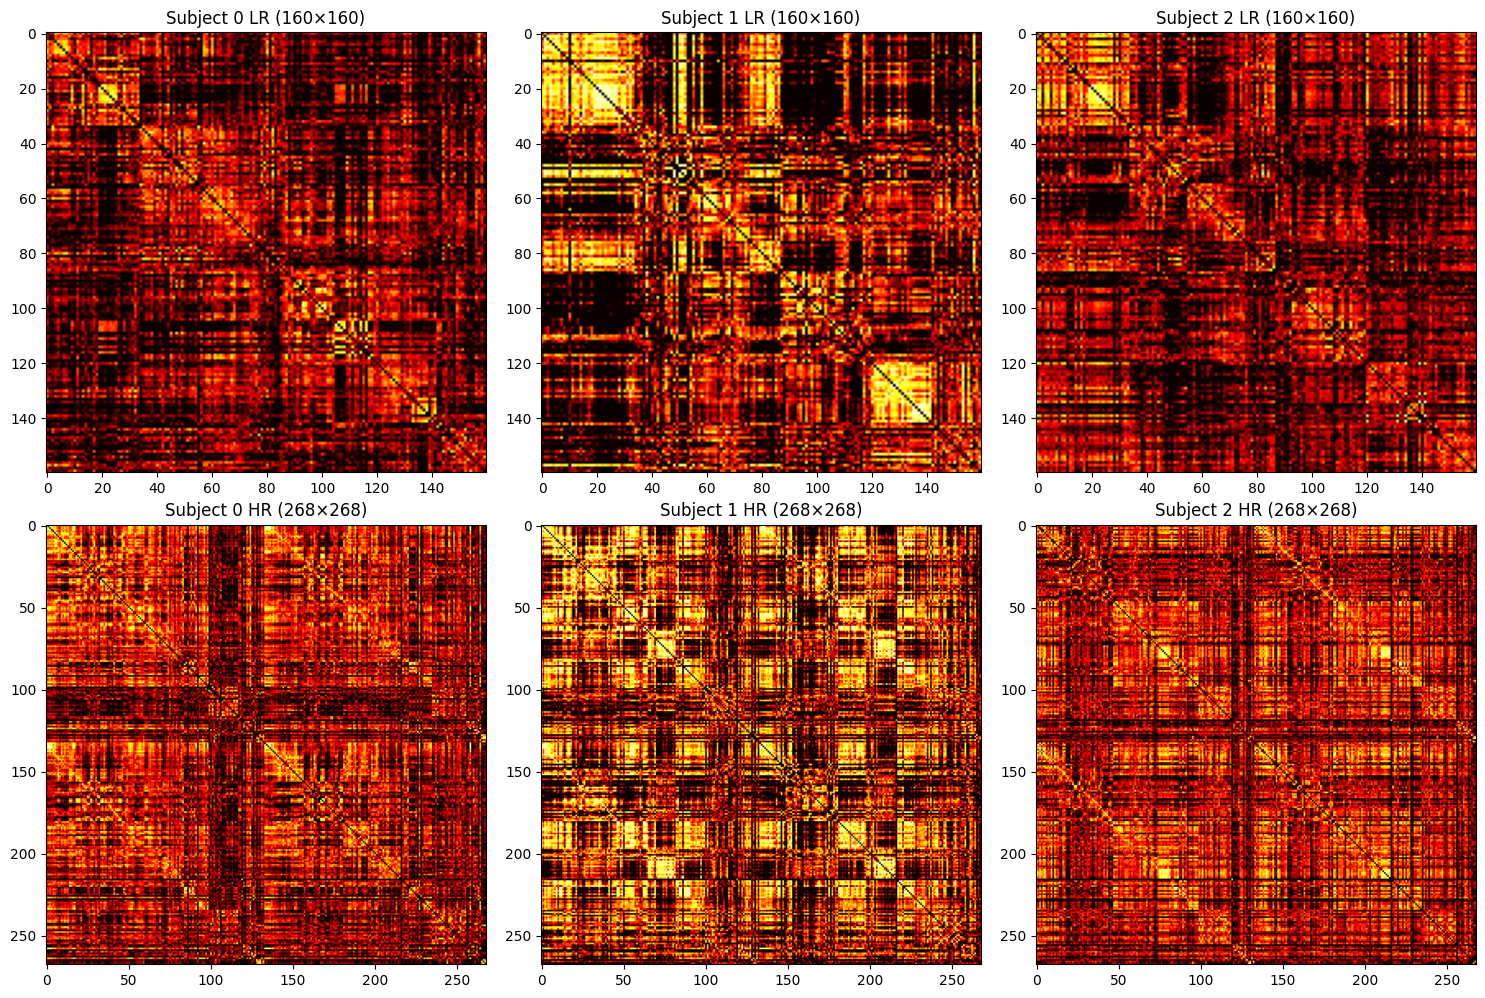

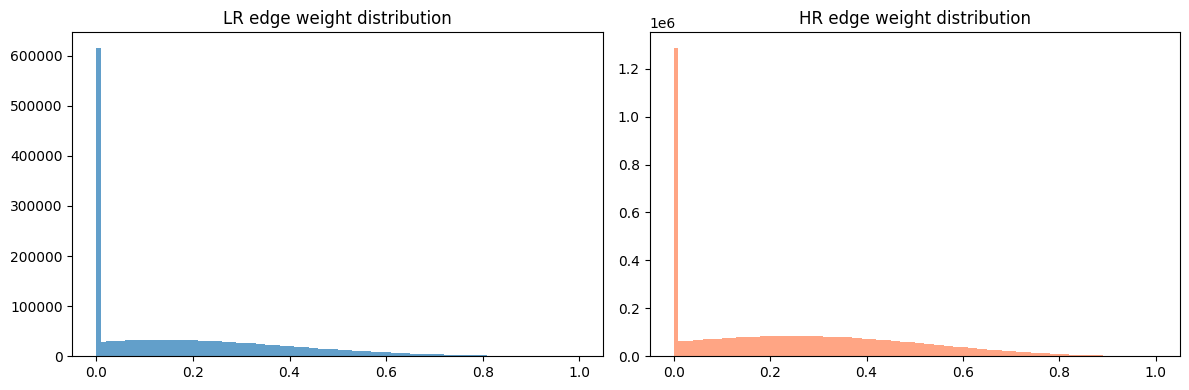

In [4]:

# Load data
lr_train = pd.read_csv(f"{DATA_DIR}/lr_train.csv").values
hr_train = pd.read_csv(f"{DATA_DIR}/hr_train.csv").values
lr_test = pd.read_csv(f"{DATA_DIR}/lr_test.csv").values

print(f"LR Train: {lr_train.shape}")
print(f"HR Train: {hr_train.shape}")
print(f"LR Test:  {lr_test.shape}")

# Anti-vectorize first subject
N_LR, N_HR = 160, 268
N_LR_VEC, N_HR_VEC = 12720, 35778
lr_mat = MatrixVectorizer().anti_vectorize(lr_train[0], N_LR)
hr_mat = MatrixVectorizer().anti_vectorize(hr_train[0], N_HR)

print(f"\nLR matrix: {lr_mat.shape}, symmetric={np.allclose(lr_mat, lr_mat.T)}, range=[{lr_mat.min():.4f}, {lr_mat.max():.4f}]")
print(f"HR matrix: {hr_mat.shape}, symmetric={np.allclose(hr_mat, hr_mat.T)}, range=[{hr_mat.min():.4f}, {hr_mat.max():.4f}]")
print(f"LR sparsity (==0): {(lr_train==0).mean()*100:.1f}%")
print(f"HR sparsity (==0): {(hr_train==0).mean()*100:.1f}%")
print(f"LR mean: {lr_train.mean():.4f}, HR mean: {hr_train.mean():.4f}")
print(f"LR-HR subject mean correlation: {np.corrcoef(lr_train.mean(1), hr_train.mean(1))[0,1]:.4f}")

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i in range(3):
    lm = MatrixVectorizer().anti_vectorize(lr_train[i], N_LR)
    hm = MatrixVectorizer().anti_vectorize(hr_train[i], N_HR)
    axes[0,i].imshow(lm, cmap='hot', vmin=0, vmax=1); axes[0,i].set_title(f'Subject {i} LR (160×160)')
    axes[1,i].imshow(hm, cmap='hot', vmin=0, vmax=1); axes[1,i].set_title(f'Subject {i} HR (268×268)')
plt.tight_layout(); plt.show()

# Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(lr_train.flatten(), bins=100, alpha=0.7); axes[0].set_title('LR edge weight distribution')
axes[1].hist(hr_train.flatten(), bins=100, alpha=0.7, color='coral'); axes[1].set_title('HR edge weight distribution')
plt.tight_layout(); plt.show()

In [4]:
def anti_vectorize_batch(vectors, N):
    """Convert batch of vectors to adjacency matrices."""
    matrices = []
    for v in vectors:
        matrices.append(MatrixVectorizer.anti_vectorize(v, N))
    return np.array(matrices)

def vectorize_batch(matrices):
    """Convert batch of adjacency matrices to vectors."""
    vectors = []
    for m in matrices:
        vectors.append(MatrixVectorizer.vectorize(m))
    return np.array(vectors)

def adj_to_edge_index_and_weights(adj, threshold=0.0):
    """Convert adjacency matrix to PyG edge_index and edge_weight."""
    # Threshold to create edges
    mask = adj > threshold
    rows, cols = np.where(mask)
    edge_index = torch.tensor(np.array([rows, cols]), dtype=torch.long)
    edge_weight = torch.tensor(adj[rows, cols], dtype=torch.float32)
    return edge_index, edge_weight

def postprocess(pred_matrices):
    """Clamp negatives to 0 and ensure zero diagonal + symmetry."""
    pred_matrices = np.clip(pred_matrices, 0, None)
    for i in range(len(pred_matrices)):
        np.fill_diagonal(pred_matrices[i], 0)
        pred_matrices[i] = (pred_matrices[i] + pred_matrices[i].T) / 2
    return pred_matrices

In [5]:
class BrainGSR(nn.Module):
    def __init__(self, n_lr=160, n_hr=268, hidden_dim=320, embedding_dim=268):
        super(BrainGSR, self).__init__()
        self.n_lr = n_lr
        self.n_hr = n_hr
        
        # Pre-compute upper triangle indices (column-major order)
        rows, cols = [], []
        for col in range(n_hr):
            for row in range(col):
                rows.append(row)
                cols.append(col)
        self.register_buffer('tri_rows', torch.tensor(rows, dtype=torch.long))
        self.register_buffer('tri_cols', torch.tensor(cols, dtype=torch.long))
        
        # GCN Encoder
        self.gc1 = GCNConv(n_lr, hidden_dim)
        self.gc2 = GCNConv(hidden_dim, embedding_dim)
        
        # Upsampling: 160 -> 268 nodes
        self.upsample = nn.Linear(n_lr, n_hr, bias=False)
        
    def forward(self, x, edge_index, edge_weight=None):
        # GCN encode
        h = F.relu(self.gc1(x, edge_index, edge_weight))
        h = self.gc2(h, edge_index, edge_weight)
        
        # Upsample: [160, 268] -> [268, 268]
        h = self.upsample.weight @ h
        
        # Inner product decoder
        pred_adj = torch.mm(h, h.t())
        pred_adj = torch.sigmoid(pred_adj)
        pred_adj = pred_adj * (1 - torch.eye(self.n_hr, device=pred_adj.device))
        pred_adj = (pred_adj + pred_adj.t()) / 2
        
        # Vectorize using pre-computed indices (fast)
        pred_hr_vec = pred_adj[self.tri_rows, self.tri_cols]
        
        return pred_hr_vec

In [6]:
def train_model(lr_matrices, hr_vectors, num_epochs=200, lr=0.001):
    """Train the model on given LR matrices and HR vectors."""
    model = BrainGSR().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.L1Loss()  # MAE loss (matches Kaggle metric)
    
    n_train = len(lr_matrices)
    losses = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        # Shuffle training order
        indices = np.random.permutation(n_train)
        
        for idx in indices:
            optimizer.zero_grad()
            
            # Prepare LR graph
            lr_adj = lr_matrices[idx]
            x = torch.tensor(lr_adj, dtype=torch.float32).to(device)  # [160, 160]
            edge_index, edge_weight = adj_to_edge_index_and_weights(lr_adj)
            edge_index = edge_index.to(device)
            edge_weight = edge_weight.to(device)
            
            # Target HR vector
            target = torch.tensor(hr_vectors[idx], dtype=torch.float32).to(device)
            
            # Forward
            pred = model(x, edge_index, edge_weight)
            
            # Loss
            loss = criterion(pred, target)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / n_train
        losses.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}")
    
    return model, losses

In [7]:
def predict(model, lr_matrices):
    """Generate HR predictions for given LR matrices."""
    model.eval()
    predictions = []
    
    with torch.no_grad():
        for i in range(len(lr_matrices)):
            lr_adj = lr_matrices[i]
            x = torch.tensor(lr_adj, dtype=torch.float32).to(device)
            edge_index, edge_weight = adj_to_edge_index_and_weights(lr_adj)
            edge_index = edge_index.to(device)
            edge_weight = edge_weight.to(device)
            
            pred_vec = model(x, edge_index, edge_weight)
            predictions.append(pred_vec.cpu().numpy())
    
    return np.array(predictions)

In [8]:
def evaluate_fold(pred_matrices, gt_matrices):
    """
    Evaluate predictions using the exact pattern from evaluation_measures.py.
    Returns dict of all 8 metrics.
    """
    num_test_samples = len(pred_matrices)
    
    # Initialize lists for centrality MAEs
    mae_bc = []
    mae_ec = []
    mae_pc = []
    
    # Initialize lists for vectorized forms
    pred_1d_list = []
    gt_1d_list = []
    
    # Custom metrics
    mae_cc = []
    mae_density = []
    
    for i in range(num_test_samples):
        # Convert adjacency matrices to NetworkX graphs
        pred_graph = nx.from_numpy_array(pred_matrices[i], edge_attr="weight")
        gt_graph = nx.from_numpy_array(gt_matrices[i], edge_attr="weight")
        
        # Compute centrality measures
        pred_bc = nx.betweenness_centrality(pred_graph, weight="weight")
        gt_bc = nx.betweenness_centrality(gt_graph, weight="weight")
        
        try:
            pred_ec = nx.eigenvector_centrality(pred_graph, weight="weight", max_iter=1000)
            gt_ec = nx.eigenvector_centrality(gt_graph, weight="weight", max_iter=1000)
            mae_ec.append(mean_absolute_error(list(pred_ec.values()), list(gt_ec.values())))
        except:
            mae_ec.append(float('nan'))
        
        pred_pc = nx.pagerank(pred_graph, weight="weight")
        gt_pc = nx.pagerank(gt_graph, weight="weight")
        
        # Compute MAEs
        mae_bc.append(mean_absolute_error(list(pred_bc.values()), list(gt_bc.values())))
        mae_pc.append(mean_absolute_error(list(pred_pc.values()), list(gt_pc.values())))
        
        # Custom metric 1: Clustering Coefficient MAE
        pred_cc = nx.average_clustering(pred_graph, weight="weight")
        gt_cc = nx.average_clustering(gt_graph, weight="weight")
        mae_cc.append(abs(pred_cc - gt_cc))
        
        # Custom metric 2: Density MAE
        mae_density.append(abs(nx.density(pred_graph) - nx.density(gt_graph)))
        
        # Vectorize matrices
        pred_1d_list.append(MatrixVectorizer.vectorize(pred_matrices[i]))
        gt_1d_list.append(MatrixVectorizer.vectorize(gt_matrices[i]))
    
    # Concatenate flattened matrices
    pred_1d = np.concatenate(pred_1d_list)
    gt_1d = np.concatenate(gt_1d_list)
    
    # Compute global metrics
    mae = mean_absolute_error(pred_1d, gt_1d)
    pcc = pearsonr(pred_1d, gt_1d)[0]
    jsd = jensenshannon(pred_1d, gt_1d)
    
    metrics = {
        'MAE': mae,
        'PCC': pcc,
        'JSD': jsd,
        'Betweenness MAE': np.nanmean(mae_bc),
        'Eigenvector MAE': np.nanmean(mae_ec),
        'PageRank MAE': np.nanmean(mae_pc),
        'Clustering Coeff MAE': np.nanmean(mae_cc),
        'Density MAE': np.nanmean(mae_density),
    }
    return metrics

In [9]:
# Convert all training data to matrices
print("Anti-vectorizing training data...")
lr_train_matrices = anti_vectorize_batch(lr_train, N_LR)
hr_train_matrices = anti_vectorize_batch(hr_train, N_HR)
print(f"LR matrices: {lr_train_matrices.shape}, HR matrices: {hr_train_matrices.shape}")

Anti-vectorizing training data...
LR matrices: (167, 160, 160), HR matrices: (167, 268, 268)


In [10]:
NUM_EPOCHS = 200
LEARNING_RATE = 0.001
SEED = 42

kf = KFold(n_splits=3, shuffle=True, random_state=SEED)

all_fold_metrics = []
fold_predictions = {}

start_time = time.time()
start_ram = psutil.Process(os.getpid()).memory_info().rss / 1e6

for fold_num, (train_idx, test_idx) in enumerate(kf.split(lr_train_matrices), 1):
    print(f"\n{'='*50}")
    print(f"FOLD {fold_num}")
    print(f"{'='*50}")
    print(f"Train: {len(train_idx)} subjects, Test: {len(test_idx)} subjects")
    
    # Split data
    fold_lr_train = lr_train_matrices[train_idx]
    fold_hr_train = hr_train[train_idx]
    fold_lr_test = lr_train_matrices[test_idx]
    fold_hr_test_mats = hr_train_matrices[test_idx]
    
    # Train
    model, losses = train_model(fold_lr_train, fold_hr_train, 
                                 num_epochs=NUM_EPOCHS, lr=LEARNING_RATE)
    
    # Predict
    pred_vectors = predict(model, fold_lr_test)
    
    # Convert predictions to matrices and post-process
    pred_matrices = anti_vectorize_batch(pred_vectors, N_HR)
    pred_matrices = postprocess(pred_matrices)
    
    # Evaluate (matching evaluation_measures.py pattern)
    metrics = evaluate_fold(pred_matrices, fold_hr_test_mats)
    all_fold_metrics.append(metrics)
    
    # Store cleaned predictions for CSV
    pred_vectors_clean = vectorize_batch(pred_matrices)
    fold_predictions[fold_num] = (test_idx, pred_vectors_clean)
    
    print(f"\nFold {fold_num} Results:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.6f}")

total_time = time.time() - start_time
end_ram = psutil.Process(os.getpid()).memory_info().rss / 1e6

print(f"\n{'='*50}")
print(f"Total training time: {total_time:.1f}s")
print(f"RAM usage: {end_ram:.0f} MB (delta: {end_ram - start_ram:.0f} MB)")


FOLD 1
Train: 111 subjects, Test: 56 subjects
  Epoch 10/200, Loss: 0.245661


  Epoch 20/200, Loss: 0.244123
  Epoch 30/200, Loss: 0.243717
  Epoch 40/200, Loss: 0.241918
  Epoch 50/200, Loss: 0.239992
  Epoch 60/200, Loss: 0.239595
  Epoch 70/200, Loss: 0.238187
  Epoch 80/200, Loss: 0.237624
  Epoch 90/200, Loss: 0.234850
  Epoch 100/200, Loss: 0.233083
  Epoch 110/200, Loss: 0.234190
  Epoch 120/200, Loss: 0.230267
  Epoch 130/200, Loss: 0.229589
  Epoch 140/200, Loss: 0.227433
  Epoch 150/200, Loss: 0.226987
  Epoch 160/200, Loss: 0.226032
  Epoch 170/200, Loss: 0.227611
  Epoch 180/200, Loss: 0.225284
  Epoch 190/200, Loss: 0.224562
  Epoch 200/200, Loss: 0.225249

Fold 1 Results:
  MAE: 0.247980
  PCC: 0.257893
  JSD: 0.359823
  Betweenness MAE: 100968.478275
  Eigenvector MAE: 0.017185
  PageRank MAE: 0.000715
  Clustering Coeff MAE: 0.093079
  Density MAE: 0.193705

FOLD 2
Train: 111 subjects, Test: 56 subjects
  Epoch 10/200, Loss: 0.247853
  Epoch 20/200, Loss: 0.245634
  Epoch 30/200, Loss: 0.244511
  Epoch 40/200, Loss: 0.240905
  Epoch 50/200, Loss:

In [ ]:
for fold_num in range(1, 4):
    test_idx, pred_vecs = fold_predictions[fold_num]
    
    # Flatten all predictions for this fold
    flat_preds = pred_vecs.flatten()
    
    # Create submission DataFrame
    df = pd.DataFrame({
        'ID': np.arange(1, len(flat_preds) + 1),
        'Predicted': flat_preds
    })
    
    filename = f'predictions_fold_{fold_num}.csv'
    df.to_csv(filename, index=False)
    print(f"Saved {filename}: {df.shape[0]} rows")

Saved predictions_fold_1.csv: 2003568 rows
Saved predictions_fold_2.csv: 2003568 rows
Saved predictions_fold_3.csv: 1967790 rows


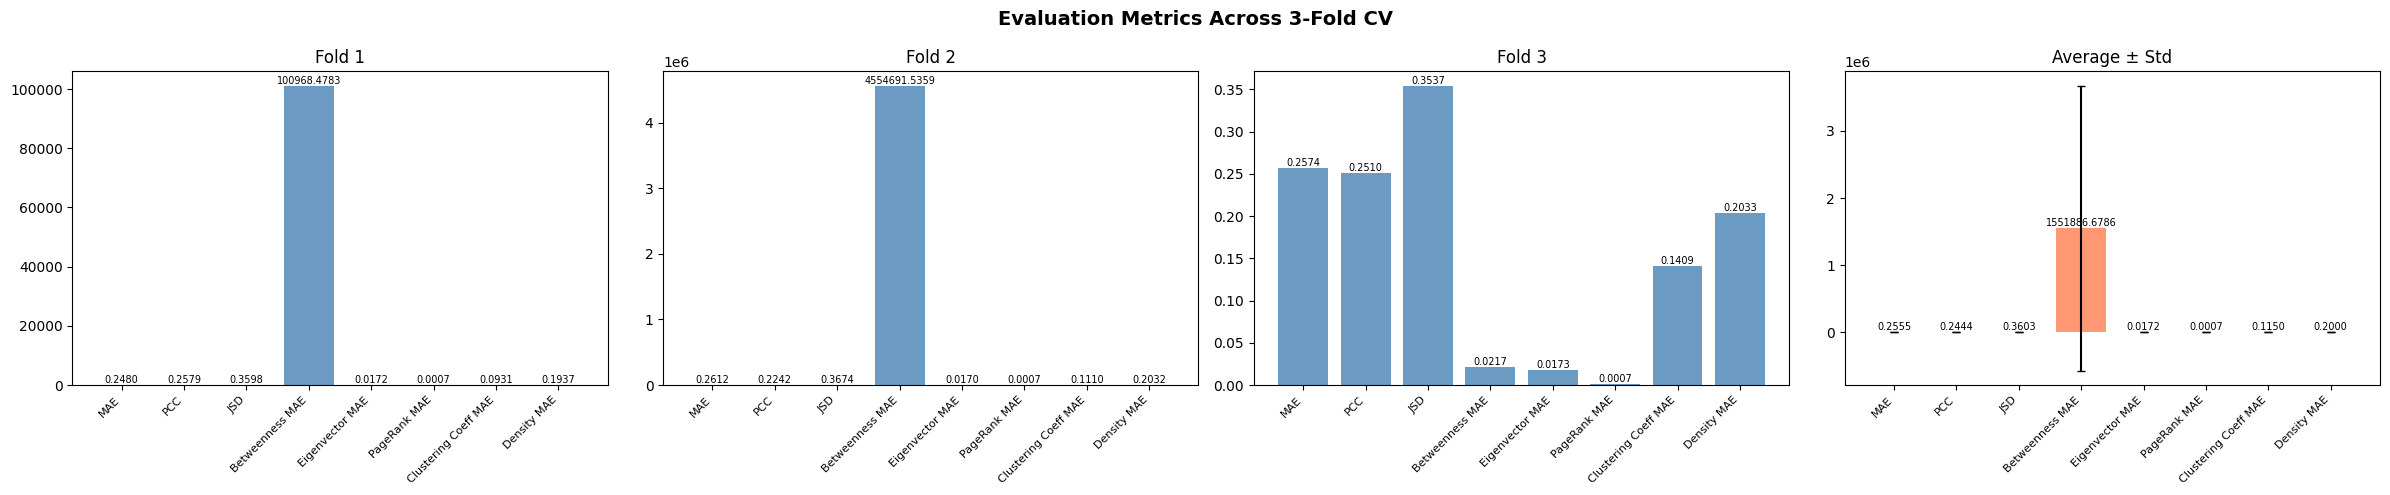


Metric                    Fold 1       Fold 2       Fold 3       Avg±Std
---------------------------------------------------------------------------
MAE                       0.247980     0.261232     0.257364     0.255525±0.005564
PCC                       0.257893     0.224179     0.250979     0.244350±0.014540
JSD                       0.359823     0.367433     0.353665     0.360307±0.005631
Betweenness MAE           100968.478275 4554691.535915 0.021712     1551886.678634±2123703.748248
Eigenvector MAE           0.017185     0.017043     0.017297     0.017175±0.000104
PageRank MAE              0.000715     0.000704     0.000736     0.000718±0.000013
Clustering Coeff MAE      0.093079     0.111043     0.140937     0.115020±0.019739
Density MAE               0.193705     0.203150     0.203258     0.200038±0.004478


In [12]:
metric_names = list(all_fold_metrics[0].keys())
n_metrics = len(metric_names)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle('Evaluation Metrics Across 3-Fold CV', fontsize=14, fontweight='bold')

# Per-fold plots
for fold_idx in range(3):
    values = [all_fold_metrics[fold_idx][m] for m in metric_names]
    bars = axes[fold_idx].bar(range(n_metrics), values, color='steelblue', alpha=0.8)
    axes[fold_idx].set_title(f'Fold {fold_idx+1}')
    axes[fold_idx].set_xticks(range(n_metrics))
    axes[fold_idx].set_xticklabels(metric_names, rotation=45, ha='right', fontsize=8)
    for bar, val in zip(bars, values):
        axes[fold_idx].text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                           f'{val:.4f}', ha='center', va='bottom', fontsize=7)

# Average with error bars
avg_values = [np.mean([all_fold_metrics[f][m] for f in range(3)]) for m in metric_names]
std_values = [np.std([all_fold_metrics[f][m] for f in range(3)]) for m in metric_names]
bars = axes[3].bar(range(n_metrics), avg_values, yerr=std_values, 
                   color='coral', alpha=0.8, capsize=3)
axes[3].set_title('Average ± Std')
axes[3].set_xticks(range(n_metrics))
axes[3].set_xticklabels(metric_names, rotation=45, ha='right', fontsize=8)
for bar, val in zip(bars, avg_values):
    axes[3].text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                 f'{val:.4f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('evaluation_barplots.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'Metric':<25} {'Fold 1':<12} {'Fold 2':<12} {'Fold 3':<12} {'Avg±Std'}")
print("-" * 75)
for i, m in enumerate(metric_names):
    vals = [all_fold_metrics[f][m] for f in range(3)]
    print(f"{m:<25} {vals[0]:<12.6f} {vals[1]:<12.6f} {vals[2]:<12.6f} {np.mean(vals):.6f}±{np.std(vals):.6f}")